In [77]:
import matplotlib
matplotlib.rcParams["text.usetex"] = True
matplotlib.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"
import matplotlib.gridspec as gridspec
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch

In [3]:
def setup_graph():
    plt.xlim(-1, 8)
    plt.ylim(-1, 2)
    plt.xticks(range(8))
    plt.yticks([0, 1])
    plt.axhline(0, color="black", ls="--")
    plt.axvline(0, color="black", ls="--")

def configure_axes(ax):
    ax.axhline(color="black", ls="--")
    ax.axvline(color="black", ls="--")
    ax.set_xlim(-2, 5)
    ax.set_ylim(-1, 8)

# Save a figure to a file
def save_fig(fig, file_path,):
    # COMMENT OUT THIS LINE TO DISABLE SAVING
    fig.savefig(file_path, bbox_inches="tight")
    pass

import os
image_folder_name="generated_images"
os.makedirs(image_folder_name, exist_ok=True)

x = 3.5, f(x) = 2.5833333333333335
f'(x) = 1.6666666666666667


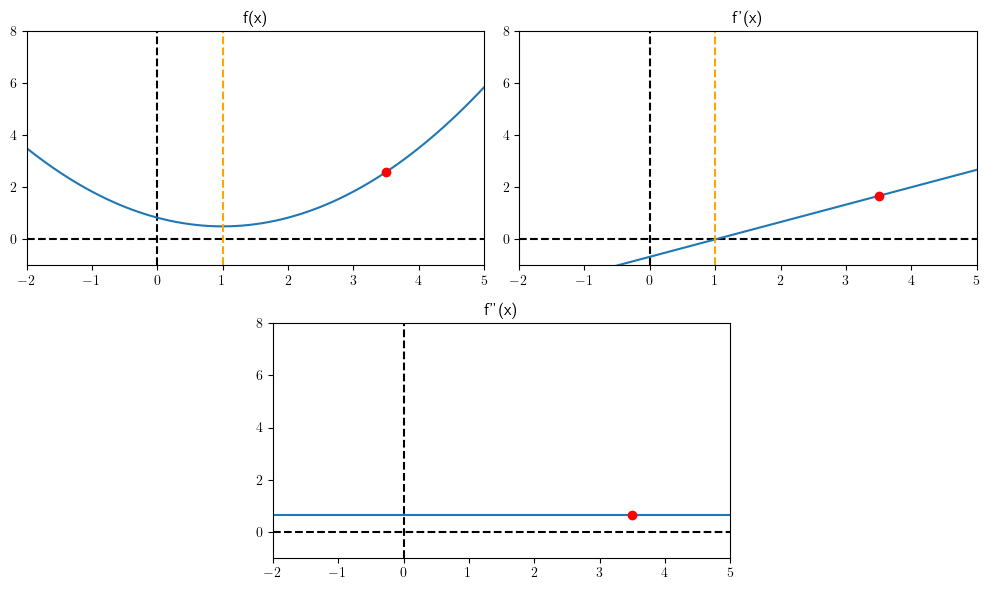

In [19]:
xs = [x/10 for x in range(-100, 100)]
ys= [((x-1)**2) /3 + 0.5 for x in xs]

fig = plt.figure(figsize=(10, 6))
gs = gridspec.GridSpec(2, 4, figure=fig)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[1, 1:3]) 
configure_axes(ax1)
configure_axes(ax2)
configure_axes(ax3)

ax1.set_title("f(x)")
ax1.plot(xs, ys)
ax1.axvline(1, color="orange", ls="--")
ax1.plot(xs[-65], ys[-65], "ro-")
print(f"x = {xs[-65]}, f(x) = {ys[-65]}")

ax2.set_title("f'(x)")
ax2.plot(xs, [2*(x-1)/3 for x in xs])
y_val = 2*(xs[-65]-1)/3
ax2.plot(xs[-65], [y_val], "ro-")
ax2.axvline(1, color="orange", ls="--")
print(f"f'(x) = {y_val}")

ax3.set_title("f''(x)")
ax3.plot(xs, [2/3 for _ in xs])
ax3.plot(xs[-65], 2/3, "ro-")
plt.tight_layout()

save_fig(fig, f"{image_folder_name}/simple_quadratic.png")

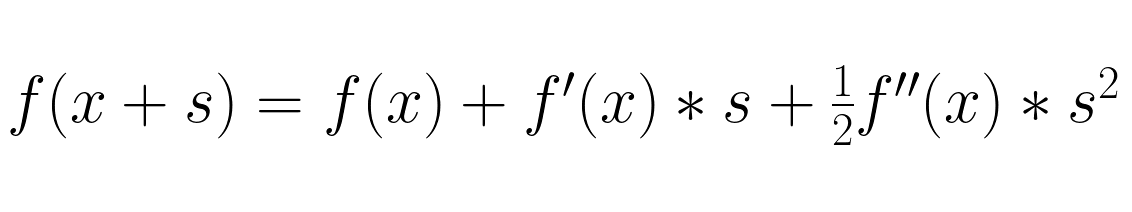

In [20]:
taylor_string = r"$f(x + s) = f(x) + f'(x)*s + \frac{1}{2} f''(x) * s^2$"

fig = plt.figure(figsize=(10, 2.5))  # Dimensions of figsize are in inches
plt.gca().axis("off")
fig.text(
    x=0.5,  # x-coordinate to place the text
    y=0.5,  # y-coordinate to place the text
    s=taylor_string,
    horizontalalignment="center",
    verticalalignment="center",
    fontsize=48,
)
save_fig(fig, f"{image_folder_name}/second_taylor.png")

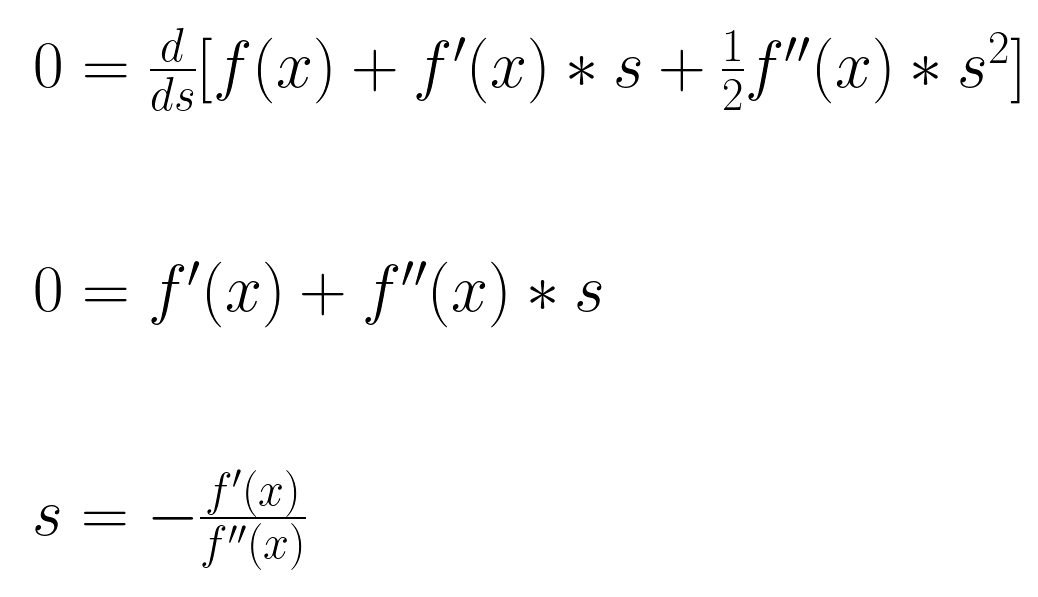

In [21]:
eq_1 = r"$0 = \frac{d}{ds}[f(x) + f'(x)*s + \frac{1}{2} f''(x) * s^2]$"
eq_2 = r"$0 = f'(x) + f''(x) * s$"
eq_3 = r"$s = -\frac{f'(x)}{f''(x)}$"

equations = [eq_1, eq_2, eq_3]

fig = plt.figure(figsize=(10, 7.5))
plt.gca().axis("off")
for (i, eq) in enumerate(equations):
        fig.text(
            x = 0.15,
            y= 0.8 - 0.3 * i,
            s=eq,
            horizontalalignment="left",
            verticalalignment="center",
            fontsize=48
        )
save_fig(fig, f"{image_folder_name}/step_calculation.png")

---

## Manim: 3D scaffold

Minimal starting point — a sloped plane in 3D — to build the optimizer animation from.
Run the config cell once, then the scene cell renders and embeds the video inline.

A few things to know as you experiment:
- Uses the **default Cairo renderer** (renders reliably in the notebook). The OpenGL
  renderer gives true depth but won't render to a movie headlessly on macOS, so avoid it here.
- To draw math equations you'll need `MathTex`, which shells out to LaTeX (installed).
- Docs: https://docs.manim.community/ — the Surface, ThreeDScene, and ThreeDAxes references
  are the relevant ones for this scene.

In [4]:
from manim import *
import numpy as np

# Inline preview size in the notebook.
config.media_width = "80%"
config.media_embed = True


In [210]:
%%manim -ql -v WARNING DescentComparisonOne
# The %%manim magic renders the named scene below and embeds the video inline.
#   -ql  = low quality / fast (use -qh for the final 1080p render)
#   The mp4 is also written under media/videos/...


starting_point = [-0.5, 1.25]


A, w = 0.1, 10
def surface_function(p):
    x, y = p
    base_quadratic = 2* x**2 + 0.6 * y**2
    noise =  A * torch.sin(w*x) * torch.sin(w*y)
    # return  x**2 + 0.8*y**2 + 0.1 * torch.cos(2*x) + 0.15 * torch.sin(2*y) + 0.1 * torch.sin(5*x) + 0.15 * torch.cos(5*y)
    return base_quadratic + noise

def record_position(p, p_list):
    p_list.append([*p.detach().tolist(), surface_function(p).item()])


p = torch.tensor(starting_point, requires_grad=True)
optimizer = torch.optim.SGD([p], lr=0.1)


positions_g = []
positions_n = []

record_position(p, positions_g)
record_position(p, positions_n)

ITERATIONS=100
i = 0
while i < ITERATIONS and positions_g[-1][2] > 0.1:
    optimizer.zero_grad()
    loss = surface_function(p)
    loss.backward()
    optimizer.step()
    record_position(p, positions_g)

p = torch.tensor(starting_point, requires_grad=True)

for _ in range(ITERATIONS):
    gradients = torch.autograd.functional.jacobian(surface_function, p)
    hessian = torch.autograd.functional.hessian(surface_function, p)
    step = torch.linalg.solve(hessian, gradients) # find x that solves for B x = df
    with torch.no_grad():
        p -= step
    record_position(p, positions_n)



print(positions_n[0:5])
print(positions_n[-5:])

class DescentComparisonOne(ThreeDScene):
    # ThreeDScene gives you a movable 3D camera. construct() is the "script":
    # everything you add()/play() here becomes the animation, in order.
    def construct(self):
        # ThreeDAxes draws the x/y/z frame. Ranges are [min, max, step].
        axes = ThreeDAxes(x_range=[-3, 3, 1], y_range=[-3, 3, 1], z_range=[-3, 3, 1])

        gradient_coords = [axes.c2p(x, y, z+0.4) for (x, y, z) in positions_g]
        newtonian_coords = [axes.c2p(x, y, z+0.4) for (x, y, z) in positions_n]

        gradient_path = VMobject().set_points_as_corners(gradient_coords)
        newtonian_path = VMobject().set_points_as_corners(newtonian_coords)

        # A Surface is defined by a function (u, v) -> a point in space.
        # axes.c2p ("coords to point") maps math coordinates onto the axes,
        # so the surface lines up with the frame. Here z is a linear slope.
        
        def scene_surface(x, y):
            p = torch.tensor([x,y], requires_grad=False)
            z = float(surface_function(p))
            return axes.c2p(x, y, z)

        surface = Surface(
            scene_surface,
            u_range=[-2, 2],
            v_range=[-2, 2],
            resolution=(16, 16),  # grid density: higher = smoother but slower
        )

        dot = Dot3D(point=gradient_coords[0], color=RED)

        # Point the camera. phi = tilt down from vertical, theta = spin around.
        self.set_camera_orientation(phi=45 * DEGREES, theta=-65 * DEGREES)
        # self.begin_ambient_camera_rotation()

        # add() puts something on screen instantly; play() animates it.
        self.add(axes)
        # self.play(Create(axes))
        # self.wait()
        self.play(Create(surface))
        # self.add(surface)
        # self.play(Create(dot))
        self.add(dot)
        # self.add(newtonian_path)
        self.play(Create(newtonian_path))
        trace = TracedPath(dot.get_center)
        self.add(trace)
        self.play(MoveAlongPath(dot, gradient_path, rate_func = rate_functions.ease_in_out_expo, run_time=3))
        self.wait()

[[-0.5, 1.25, 1.4311401844024658], [20.79851531982422, -32.92234420776367, 1515.4490966796875], [49.4194450378418, 13.809028625488281, 4998.98779296875], [52.569007873535156, 50.44454574584961, 7053.70751953125], [36.09082794189453, 46.01791000366211, 3875.72119140625]]
[[49.2983512878418, 1057.45166015625, 675783.0625], [192.68447875976562, 1140.2677001953125, 854380.9375], [318.9913330078125, 1308.1605224609375, 1230281.375], [1262.6121826171875, 2723.48583984375, 7638804.0], [952.3018798828125, 2302.497314453125, 4994654.0]]


Manim Community v0.20.1

In [ ]:
%%manim -ql -v WARNING DescentComparisonTwo
# The %%manim magic renders the named scene below and embeds the video inline.
#   -ql  = low quality / fast (use -qh for the final 1080p render)
#   The mp4 is also written under media/videos/...


starting_point = [-0.5, 1.25]


a, b = 1, 2
def surface_function(p):
    x, y = p
    rosenbrock = (a - x)**2 + b*(y-x**2)**2
    return rosenbrock

def record_position(p, p_list):
    p_list.append([*p.detach().tolist(), surface_function(p).item()])


p = torch.tensor(starting_point, requires_grad=True)
optimizer = torch.optim.SGD([p], lr=0.01)


positions_g = []
positions_n = []

record_position(p, positions_g)
record_position(p, positions_n)

ITERATIONS=1000

for _ in range(ITERATIONS):
    optimizer.zero_grad()
    loss = surface_function(p)
    loss.backward()
    optimizer.step()
    record_position(p, positions_g)

p = torch.tensor(starting_point, requires_grad=True)

for _ in range(5):
    gradients = torch.autograd.functional.jacobian(surface_function, p)
    hessian = torch.autograd.functional.hessian(surface_function, p)
    step = torch.linalg.solve(hessian, gradients) # find x that solves for B x = df
    with torch.no_grad():
        p -= step
    record_position(p, positions_n)



print(positions_n[0:5])
print(positions_n[-5:])

class DescentComparisonTwo(ThreeDScene):
    # ThreeDScene gives you a movable 3D camera. construct() is the "script":
    # everything you add()/play() here becomes the animation, in order.
    def construct(self):
        # ThreeDAxes draws the x/y/z frame. Ranges are [min, max, step].
        axes = ThreeDAxes(x_range=[-2, 2, 1], y_range=[-3, 3, 1], z_range=[-0, 2, 1])

        gradient_coords = [axes.c2p(x, y, z+0.4) for (x, y, z) in positions_g]
        newtonian_coords = [axes.c2p(x, y, z+0.4) for (x, y, z) in positions_n]

        gradient_path = VMobject().set_points_as_corners(gradient_coords)
        newtonian_path = VMobject().set_points_as_corners(newtonian_coords)

        # A Surface is defined by a function (u, v) -> a point in space.
        # axes.c2p ("coords to point") maps math coordinates onto the axes,
        # so the surface lines up with the frame. Here z is a linear slope.
        
        def scene_surface(x, y):
            p = torch.tensor([x,y], requires_grad=False)
            z = float(surface_function(p))
            return axes.c2p(x, y, z)

        surface = Surface(
            scene_surface,
            u_range=[-1, 1],
            v_range=[-1, 1],
            resolution=(16, 16),  # grid density: higher = smoother but slower
        )

        dot = Dot3D(point=gradient_coords[0], color=RED)

        # Point the camera. phi = tilt down from vertical, theta = spin around.
        self.set_camera_orientation(phi=65 * DEGREES, theta=45 * DEGREES, zoom=0.4)
        # self.begin_ambient_camera_rotation()

        # add() puts something on screen instantly; play() animates it.
        self.add(axes)
        # self.play(Create(axes))
        # self.wait()
        self.play(Create(surface))
        # self.add(surface)
        # self.play(Create(dot))
        self.add(dot)
        # self.add(newtonian_path)
        self.play(Create(newtonian_path))
        trace = TracedPath(dot.get_center)
        self.add(trace)
        self.play(MoveAlongPath(dot, gradient_path, rate_func = rate_functions.ease_in_out_expo, run_time=3))
        self.wait()

[[-0.5, 1.25, 4.25], [-1.0, 0.75, 4.125], [1.1920928955078125e-07, -1.000000238418579, 3.0000007152557373], [0.20000004768371582, 0.0, 0.6431999206542969], [0.8896551728248596, 0.31586211919784546, 0.464612752199173]]
[[-1.0, 0.75, 4.125], [1.1920928955078125e-07, -1.000000238418579, 3.0000007152557373], [0.20000004768371582, 0.0, 0.6431999206542969], [0.8896551728248596, 0.31586211919784546, 0.464612752199173], [0.9276723861694336, 0.8591307997703552, 0.005235461052507162]]


Manim Community v0.20.1